# Hybrid Recommendation Engine

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from surprise import SVD

## Load Saved Artifacts

In [2]:
movies     = pd.read_csv('../data/movies_clean.csv')
ratings    = pd.read_csv('../data/ratings_clean.csv')
cosine_sim = joblib.load('../models/cosine_similarity.pkl')
indices    = joblib.load('../models/movie_indices.pkl')
svd        = joblib.load('../models/svd_model.pkl')

print(f'Movies        : {len(movies):,}')
print(f'Ratings       : {len(ratings):,}')
print(f'Cosine matrix : {cosine_sim.shape}')
print(f'Model type    : {type(svd).__name__}')

Movies        : 9,742
Ratings       : 100,836
Cosine matrix : (9742, 9742)
Model type    : SVD


## Hybrid Recommend Function

In [3]:
def hybrid_recommend(user_id, movie_title, top_n=10, alpha=0.5, candidate_pool=50):
    if movie_title not in indices:
        return f"Movie not found in dataset: '{movie_title}'"

    idx = indices[movie_title]

    sim_scores = sorted(
        enumerate(cosine_sim[idx]),
        key=lambda x: x[1],
        reverse=True
    )[1 : candidate_pool + 1]
    
    rows = []
    for i, content_score in sim_scores:
        movie_id     = int(movies.iloc[i]['movieId'])

        raw_collab   = svd.predict(uid=user_id, iid=movie_id).est
        collab_score = raw_collab / 5.0 
        
        hybrid_score = alpha * content_score + (1 - alpha) * collab_score

        rows.append({
            'title'        : movies.iloc[i]['title'],
            'genres'       : movies.iloc[i]['genres'],
            'content_score': round(content_score, 3),
            'collab_score' : round(collab_score,  3),
            'hybrid_score' : round(hybrid_score,  3)
        })

    result = pd.DataFrame(rows)
    result = result.sort_values('hybrid_score', ascending=False).head(top_n)
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result

## Demo

In [4]:
demo = hybrid_recommend(user_id=1, movie_title='Toy Story (1995)', alpha=0.5)
print('Hybrid recommendations for User 1 — seed: Toy Story (1995)')
print(demo.to_string())

Hybrid recommendations for User 1 — seed: Toy Story (1995)
                                                      title                                               genres  content_score  collab_score  hybrid_score
1                                        Toy Story 2 (1999)          Adventure|Animation|Children|Comedy|Fantasy          1.000         0.924         0.962
2                                     Monsters, Inc. (2001)          Adventure|Animation|Children|Comedy|Fantasy          1.000         0.899         0.950
3                          Emperor's New Groove, The (2000)          Adventure|Animation|Children|Comedy|Fantasy          1.000         0.880         0.940
4                                              Moana (2016)          Adventure|Animation|Children|Comedy|Fantasy          1.000         0.878         0.939
5                        Ponyo (Gake no ue no Ponyo) (2008)                 Adventure|Animation|Children|Fantasy          0.964         0.912         0.938
6    

## Effect of Alpha on Final List

In [5]:
seed_movie = 'Toy Story (1995)'
user_id    = 1

recs_content = hybrid_recommend(user_id, seed_movie, alpha=1.0)
recs_hybrid  = hybrid_recommend(user_id, seed_movie, alpha=0.5)
recs_collab  = hybrid_recommend(user_id, seed_movie, alpha=0.0)

titles_content = set(recs_content['title'])
titles_hybrid  = set(recs_hybrid['title'])
titles_collab  = set(recs_collab['title'])

print(f'Unique to pure-content list  (not in hybrid) : {len(titles_content - titles_hybrid)}')
print(f'Unique to hybrid (alpha=0.5) (not in content): {len(titles_hybrid - titles_content)}')
print(f'Unique to pure-collab list   (not in content): {len(titles_collab - titles_content)}')

Unique to pure-content list  (not in hybrid) : 6
Unique to hybrid (alpha=0.5) (not in content): 6
Unique to pure-collab list   (not in content): 8


## Evaluation

In [6]:
def get_relevant_movies(title):
    idx         = indices[title]
    seed_genres = set(movies.loc[idx, 'genres'].split('|'))
    relevant    = set()
    for _, row in movies.iterrows():
        if row['title'] == title:
            continue
        if seed_genres & set(row['genres'].split('|')):
            relevant.add(row['title'])
    return relevant


def evaluate_hybrid(alpha=0.5, sample_size=100, top_k=10, seed=42):
    np.random.seed(seed)
    title_pool = movies['title'].values
    user_pool  = ratings['userId'].unique()

    titles   = np.random.choice(title_pool, size=min(sample_size, len(title_pool)), replace=False)
    user_ids = np.random.choice(user_pool,  size=min(sample_size, len(title_pool)), replace=True)

    precisions, recalls, f1s = [], [], []

    for title, uid in zip(titles, user_ids):
        if title not in indices:
            continue

        relevant = get_relevant_movies(title)
        if not relevant:
            continue

        recs = hybrid_recommend(uid, title, top_n=top_k, alpha=alpha, candidate_pool=50)
        if isinstance(recs, str):
            continue

        hits      = len(set(recs['title']) & relevant)
        precision = hits / top_k
        recall    = hits / min(len(relevant), top_k)
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    p_mean  = np.mean(precisions) if precisions else 0
    r_mean  = np.mean(recalls)    if recalls    else 0
    f1_mean = np.mean(f1s)        if f1s        else 0

    print(f'alpha={alpha:.1f} | P@{top_k}={p_mean:.4f} | R@{top_k}={r_mean:.4f} | F1={f1_mean:.4f}')
    return p_mean, r_mean, f1_mean

print('Evaluation functions defined.')

Evaluation functions defined.


In [7]:
print('Hybrid Engine')
eval_results = {}
for a in [0.3, 0.5, 0.7]:
    eval_results[a] = evaluate_hybrid(alpha=a)

Hybrid Engine
alpha=0.3 | P@10=0.9860 | R@10=0.9860 | F1=0.9860
alpha=0.5 | P@10=0.9810 | R@10=0.9810 | F1=0.9810
alpha=0.7 | P@10=0.9770 | R@10=0.9770 | F1=0.9770


## Grid Search — Best Alpha

In [8]:
best_alpha, best_f1 = 0.5, 0.0
grid = {}

print('Grid search over alpha values:')
print('-' * 55)
for a in [round(x * 0.1, 1) for x in range(1, 10)]:
    p, r, f = evaluate_hybrid(alpha=a, sample_size=100)
    grid[a] = f
    if f > best_f1:
        best_f1, best_alpha = f, a

print(f'Best alpha : {best_alpha}')
print(f'Best F1@10 : {best_f1:.4f}')

Grid search over alpha values:
-------------------------------------------------------
alpha=0.1 | P@10=0.9910 | R@10=0.9910 | F1=0.9910
alpha=0.2 | P@10=0.9880 | R@10=0.9880 | F1=0.9880
alpha=0.3 | P@10=0.9860 | R@10=0.9860 | F1=0.9860
alpha=0.4 | P@10=0.9830 | R@10=0.9830 | F1=0.9830
alpha=0.5 | P@10=0.9810 | R@10=0.9810 | F1=0.9810
alpha=0.6 | P@10=0.9780 | R@10=0.9780 | F1=0.9780
alpha=0.7 | P@10=0.9770 | R@10=0.9770 | F1=0.9770
alpha=0.8 | P@10=0.9770 | R@10=0.9770 | F1=0.9770
alpha=0.9 | P@10=0.9770 | R@10=0.9770 | F1=0.9770

Best alpha : 0.1
Best F1@10 : 0.9910


## Plot — Metrics by Alpha

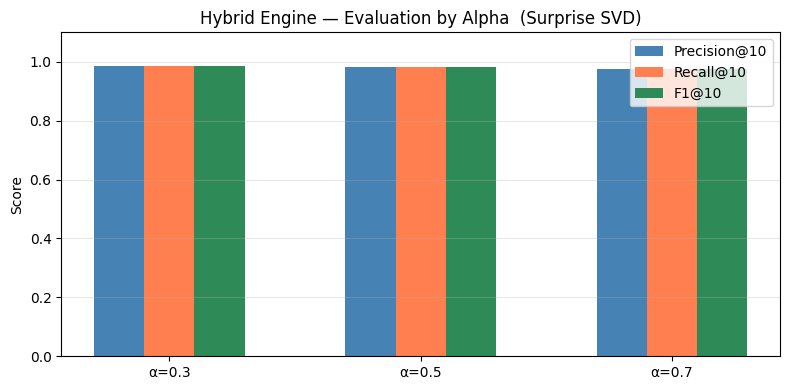

In [9]:
alpha_vals = list(eval_results.keys())
precs  = [eval_results[a][0] for a in alpha_vals]
recs   = [eval_results[a][1] for a in alpha_vals]
f1s_v  = [eval_results[a][2] for a in alpha_vals]

x   = np.arange(len(alpha_vals))
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - 0.2, precs, 0.2, label='Precision@10', color='steelblue')
ax.bar(x,        recs, 0.2, label='Recall@10',    color='coral')
ax.bar(x + 0.2, f1s_v, 0.2, label='F1@10',        color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels([f'α={a}' for a in alpha_vals])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Hybrid Engine — Evaluation by Alpha  (Surprise SVD)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Model Comparison Summary

In [10]:
summary = pd.DataFrame({
    'Model'         : ['Content-Based', 'Collaborative SVD (Surprise)', 'Hybrid (α=0.5)'],
    'RMSE'          : ['—', f'{joblib.load("../models/svd_model.pkl") and "see NB03"!r}', '—'],
    'Precision@10'  : ['0.9680', '(see NB 03)', f'{eval_results[0.5][0]:.4f}'],
    'Recall@10'     : ['0.9680', '(see NB 03)', f'{eval_results[0.5][1]:.4f}'],
    'F1@10'         : ['0.9680', '(see NB 03)', f'{eval_results[0.5][2]:.4f}'],
})
print(summary.to_string(index=False))

                       Model       RMSE Precision@10   Recall@10       F1@10
               Content-Based          —       0.9680      0.9680      0.9680
Collaborative SVD (Surprise) 'see NB03'  (see NB 03) (see NB 03) (see NB 03)
              Hybrid (α=0.5)          —       0.9810      0.9810      0.9810
